# ARTI 403 - Image Processing
### Lab 1 - Basics of programming with Python

Outcome: explain how digital images are represented and manipulated in a computer.

Tools: Anaconda / Jupyter, Python 3

## Task 1 - Setup check

Anaconda already comes with numpy + matplotlib, so I only had to install opencv
and scikit-image. Leaving the pip line here (commented) in case I run this on
another machine.

In [3]:
!pip install opencv-python scikit-image pillow matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp314-cp314-win_amd64.whl.metadata (126 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.64.0-cp314-cp314-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl (72 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --

## Task 2 - Loading and visualizing images

<class 'numpy.ndarray'> (512, 512, 3)


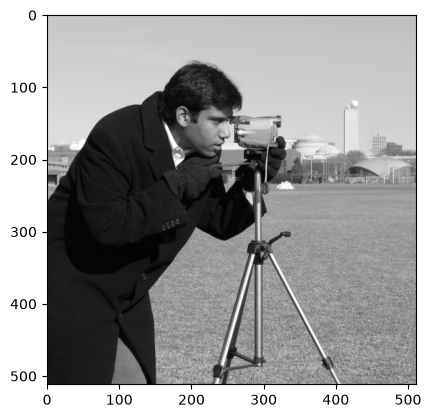

In [4]:
img = cv2.imread('images/cameraman.tif')   
print(type(img), img.shape)

plt.imshow(img)
plt.show()

## Task 3 - Storing images

In [5]:
cv2.imwrite('new_image.jpg', img)

import os
f = 'new_image.jpg'
print(f, '->', os.path.getsize(f), 'bytes')

new_image.jpg -> 86612 bytes


Both saved fine. The jpg is much smaller than the original tif because jpg is
lossy compression while tif here is uncompressed.

## Task 4 - Display the image as an array

In [6]:
print(img.shape)   # (rows, cols, channels) - opencv gives a numpy array directly
print(img)

(512, 512, 3)
[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]


In [7]:
img_array = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("shape:", img_array.shape)
print("dtype:", img_array.dtype)

shape: (512, 512)
dtype: uint8


In [8]:
# what the numbers actually mean
print("dtype        :", img_array.dtype)
print("min / max    :", img_array.min(), "/", img_array.max())
print("total pixels :", img_array.size)

# top-left 8x8 corner - each value is one pixel intensity 0=black 255=white
print(img_array[:8, :8])

dtype        : uint8
min / max    : 0 / 255
total pixels : 262144
[[200 200 200 200 199 200 199 198]
 [200 199 199 200 199 200 199 198]
 [199 199 199 200 200 200 200 200]
 [200 200 199 199 199 199 199 199]
 [200 200 200 200 199 199 199 200]
 [200 199 199 200 199 199 199 199]
 [200 201 200 200 199 200 198 199]
 [201 200 200 200 200 199 199 200]]


## Assessment - numpy operations on the image array

Trying out a few array operations on the image to see what they do visually.

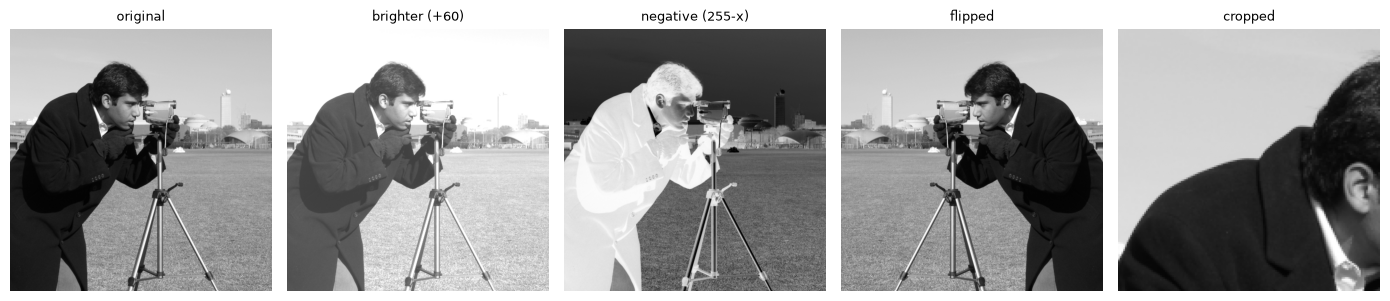

In [9]:
brighter = np.clip(img_array.astype(np.int16) + 60, 0, 255).astype(np.uint8)
negative = 255 - img_array
flipped  = np.fliplr(img_array)
cropped  = img_array[50:200, 50:200]

titles = ['original', 'brighter (+60)', 'negative (255-x)', 'flipped', 'cropped']
images = [img_array, brighter, negative, flipped, cropped]

plt.figure(figsize=(14, 3))
for i, (t, im) in enumerate(zip(titles, images)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

The `astype(np.int16)` before adding matters - if I add 60 straight to a uint8
array the values above 195 wrap around to 0 and the bright parts turn black.

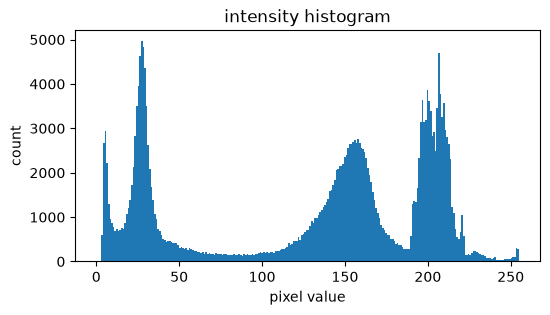

In [10]:
# histogram - how the intensities are distributed
plt.figure(figsize=(6, 3))
plt.hist(img_array.ravel(), bins=256, range=(0, 255))
plt.title('intensity histogram')
plt.xlabel('pixel value')
plt.ylabel('count')
plt.show()

threshold used: 129.06
white pixels  : 167067 of 262144


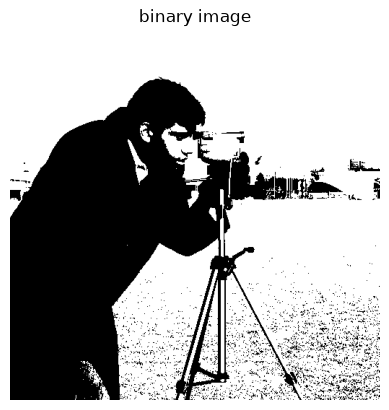

In [11]:
# simple thresholding, done with pure numpy
mask = img_array > img_array.mean()
binary = (mask * 255).astype(np.uint8)

print("threshold used:", round(img_array.mean(), 2))
print("white pixels  :", mask.sum(), "of", mask.size)

plt.imshow(binary, cmap='gray')
plt.title('binary image')
plt.axis('off')
plt.show()

### What I learned

- An image is just a numpy array of numbers: 2D for grayscale, 3D (rows, cols, 3)
  for colour.
- OpenCV reads in BGR order, PIL/matplotlib use RGB - mixing them up is what made
  the first plot look wrong.
- `cv2.imread` gives a numpy array straight away.
- Because it is only an array, normal numpy operations (add, subtract, slice, flip,
  compare) are already real image processing operations - brightness, negative,
  crop, flip, threshold.